## Figure 3: Building duplex consensus metrics and metrics compilation output

This script is used to generate the following plots:

**e**: Percentage of molecules aligned within the targeted regions for 10 different experiments, generated by the Integrated duplex metrics.

**f** and **g**: Optimal libraries



In [1]:
# --- 1. Setup: imports --------------------------------------------------------

import pandas as pd
import os
import re
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.api as sm
import numpy as np

In [2]:
# # --- 2. Paths -------------------------------------------------
# # Wetlab analysis data
# wetlab_analysis_dir = '/data/bbg/projects/prominent/analysis/wetlab_analysis/data'

# # Plots directory
# plotsdir = f"{wetlab_analysis_dir}/plots"

# # Integrated duplex metrics
# data = pd.read_table("/data/bbg/projects/prominent/analysis/wetlab_analysis/data/output_data/2026-03-18.WetDryMetrics.tsv")

In [3]:
# data["OptimalReadXDuplexRead"] = (data['FamMetrics>>total_GBs_for_optimal']/300*1e9) / data['FamMetrics>>all.duplex.dscs']

In [4]:
# subset_data_IDT = pd.read_table("../SelectedMetrics_deepDLP - Sup. Table 4_ deepDLP duplex metrics.tsv")
# subset_data_MNE = pd.read_table("../SelectedMetrics_deepDLP - Sup. Table_ ALT_deepDLP duplex metrics.tsv")
# adding_real_depth = pd.concat((subset_data_MNE, subset_data_IDT))[["SAMPLE_ID", "REAL_MEAN_DEPTH_ONTARGET"]]
# adding_real_depth = adding_real_depth[~(adding_real_depth["SAMPLE_ID"].isin(["IC003_C_1_H_1", "IC004_C_1_H_1"]))]
# adding_real_depth

In [5]:
# data = data.merge(adding_real_depth, left_on="IRB_subsample_id", right_on="SAMPLE_ID",
#                                 how = 'left'
#                                 )

In [6]:
# data["Combined>>recovery.input_ng2duplex_depth"] = data["Combined>>recovery.input_ng2duplex_depth"] * (
#     data["REAL_MEAN_DEPTH_ONTARGET"] / data["BamQC>>duplex.mean_coverage"]
# )

In [7]:
# data_to_use = data[['PROJECT', 'IRB_subsample_id', 'Sample ID',
#                     'BamQC>>raw.percentage_aligned_on_target','ANALYSIS_BATCH',
#                     'BamQC>>am.percentage_aligned_on_target',
#                     'BamQC>>duplex.percentage_aligned_on_target',
#                     'FamMetrics>>on_target.unique_molecules_perc',
#                     'DryLab>>on_target.duplex.efficiency',
#                     'Combined>>unique_molecules_obs/exp1',
#                     'Combined>>unique_molecules_obs/exp6',
#                     'Combined>>recovery.input_ng2duplex_depth',
#                     'Combined>>recovery.lig_ng2duplex_depth',
#                     'Combined>>recovery.qpcr_ng2duplex_depth',
#                     "OptimalReadXDuplexRead",
#                     "REAL_MEAN_DEPTH_ONTARGET"
#                     ]].copy()
# data_to_use = data_to_use[(data_to_use["PROJECT"].str.startswith("IDT"))
#                                 | ~(data_to_use["REAL_MEAN_DEPTH_ONTARGET"].isna())]
# data_to_use.to_csv("../data/WetDryMetrics_4_protocols.tsv", sep="\t", index=False)

In [8]:
data_to_use = pd.read_table("../data/WetDryMetrics_4_protocols.tsv")
data_to_use

,PROJECT,IRB_subsample_id,Sample ID,BamQC>>raw.percentage_aligned_on_target,ANALYSIS_BATCH,BamQC>>am.percentage_aligned_on_target,BamQC>>duplex.percentage_aligned_on_target,FamMetrics>>on_target.unique_molecules_perc,DryLab>>on_target.duplex.efficiency,Combined>>unique_molecules_obs/exp1,Combined>>unique_molecules_obs/exp6,Combined>>recovery.input_ng2duplex_depth,Combined>>recovery.lig_ng2duplex_depth,Combined>>recovery.qpcr_ng2duplex_depth,OptimalReadXDuplexRead,REAL_MEAN_DEPTH_ONTARGET
0,NEB005,AW001_R_1_H_1,NEB005_18,84.642058,NOV83,84.425268,96.663321,0.809067,0.052544,6.522342,1.083446,0.039431,0.143509,0.514194,26.423851,6571.88
1,NEB005,AW001_S_1_H_1,NEB005_16,83.233325,NOV83,82.987490,96.148776,0.780536,0.062559,9.619260,1.597884,0.029774,0.138948,0.711764,26.593429,4962.36
2,NEB005,AW002_L_1_H_1,NEB005_19,85.084075,NOV83,86.951300,96.858488,0.833071,0.054296,7.224768,1.200128,0.038808,0.132498,0.618379,28.817338,6467.94
3,NEB005,AW002_S_1_H_1,NEB005_22,86.182003,NOV83,86.117192,96.939275,0.846527,0.048591,7.365387,1.223486,0.037692,0.124592,0.579761,27.882915,6281.92
4,IDT017,B_1_1_H_1,IDT017_01,87.238811,NOV64and65,89.407926,97.667630,0.840910,0.029007,9.662998,1.605149,NaN,0.084102,1.642688,40.160130,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,IDT020,SP009_B1_1_H_2,IDT020_06,84.621022,NOV67-68,85.345157,98.238407,0.831581,0.011230,8.374798,1.391162,NaN,0.036700,0.261279,78.658863,NaN
140,NEB001,SP009_B1_1_H_3,NEB001_07,85.022867,NOV80,77.139902,98.257944,0.708871,0.049334,6.997887,1.162440,0.042561,0.165448,0.748819,25.412164,7093.49
141,NEB001,SP009_B1_1_H_4,NEB001_08,87.330604,NOV80,79.614866,98.008716,0.738485,0.042507,5.949829,0.988344,0.032567,0.142819,0.659622,24.103501,5427.76
142,IDT020,SP009_S0_1_H_1,IDT020_07,86.657367,NOV67-68,85.241062,97.354551,0.843078,0.023868,16.560883,2.750977,NaN,0.036469,0.593524,51.219987,NaN


### ON TARGET percentages

In [9]:
subset_data = data_to_use
subset_data['FamMetrics>>on_target'] = subset_data['FamMetrics>>on_target.unique_molecules_perc'] * 100
subset_data[subset_data["PROJECT"].str.startswith("IDT")].groupby("PROJECT")[['BamQC>>raw.percentage_aligned_on_target',
                                                                                'BamQC>>am.percentage_aligned_on_target',
                                                                                'BamQC>>duplex.percentage_aligned_on_target',
                                                                                'FamMetrics>>on_target'
                                                                                ]].mean()

,BamQC>>raw.percentage_aligned_on_target,BamQC>>am.percentage_aligned_on_target,BamQC>>duplex.percentage_aligned_on_target,FamMetrics>>on_target
PROJECT,,,,
IDT004,83.235528,65.922771,95.893145,65.675941
IDT006,81.463189,62.268431,94.567056,60.769887
IDT007,81.953577,82.161230,94.693844,81.421115
IDT009,82.751753,73.162604,94.548486,64.985368
IDT012,84.134587,80.992156,96.436432,73.894479
IDT013,84.222041,83.692852,96.550905,76.565385
IDT014,85.193922,85.932340,97.202740,76.920388
IDT015,78.674647,69.325030,96.878530,57.587165
IDT016,87.163515,83.965613,97.600737,76.841986


In [10]:
sorted(subset_data["PROJECT"].unique())

['IDT004',
 'IDT006',
 'IDT007',
 'IDT009',
 'IDT012',
 'IDT013',
 'IDT014',
 'IDT015',
 'IDT016',
 'IDT017',
 'IDT018',
 'IDT019',
 'IDT020',
 'IDT021',
 'IDT022',
 'IDT023',
 'IDT026',
 'IDT027',
 'IDT028',
 'MNE038',
 'NEB001',
 'NEB004',
 'NEB005',
 'NEB006',
 'NEB007']

/tmp/ipykernel_259139/2749393590.py:58: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


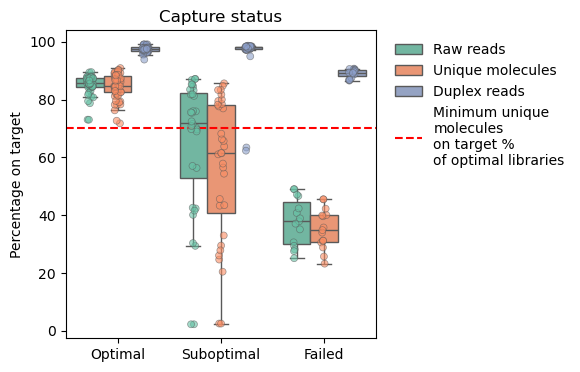

In [11]:
# your variables of interest
to_plot = [
    'BamQC>>raw.percentage_aligned_on_target',
    'BamQC>>am.percentage_aligned_on_target',
    'BamQC>>duplex.percentage_aligned_on_target',
    # 'FamMetrics>>on_target'
]

# subset data
df = subset_data[subset_data["PROJECT"].str.startswith("IDT")].copy()
df = df[df["PROJECT"].isin([
    'IDT007', 'IDT012', 'IDT013', 'IDT014',
                             'IDT016', 'IDT017', 'IDT018','IDT020',
                             'IDT015','IDT021', 'IDT022',
                             'IDT023', 'IDT019',
                             'IDT026',
                             'IDT027',
                             ])].copy()

mapping_batch_to_quality = {
        "Optimal": ['IDT007', 'IDT012', 'IDT013', 'IDT014',
                    'IDT016', 'IDT017', 'IDT018','IDT020',
                    'IDT026','IDT027',
                    ],
        "Suboptimal" : ['IDT015','IDT021', 'IDT022',],
        "Failed": [ 'IDT023', 'IDT019']
    }

df["CaptureStatus"] = df["PROJECT"].map({proj: status for status, projs in mapping_batch_to_quality.items() for proj in projs})

df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name="Percentage_on_target"
)

# rename Metric column for nicer display
long_df["Metric"] = long_df["Metric"].str.replace("BamQC>>", "").str.replace(".percentage_aligned_on_target", "")
long_df["Metric"] = long_df["Metric"].map({
    'raw': 'Raw reads',
    'am': 'Unique molecules',
    'duplex': 'Duplex reads',})
# set up plot
plt.figure(figsize=(4, 4))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y="Percentage_on_target",
    hue="Metric",
    palette="Set2",
    order = ["Optimal", "Suboptimal", "Failed"],
    showfliers=False
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y="Percentage_on_target",
    hue="Metric",
    dodge=True,
    alpha=0.6,
    order = ["Optimal", "Suboptimal", "Failed"],
    palette="Set2",
    linewidth=0.5,
    edgecolor="gray",
    legend=False
)
plt.axhline(y=70, color='red', linestyle='--', label='Minimum unique\nmolecules\non target %\nof optimal libraries')
# tidy up
plt.title("Capture status", fontsize=12)
plt.xlabel("")
plt.xticks(range(len(df["CaptureStatus"].unique())), ["Optimal", "Suboptimal", "Failed"])
plt.ylabel("Percentage on target")
# plt.xticks(range(len(df["PROJECT"].unique())), [f"Exp_{i}" for i in range(len(df["PROJECT"].unique()))])
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc='upper left', frameon =False)
# plt.tight_layout()
plt.savefig("../plots/capture_status_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()


### Conversion rate

/tmp/ipykernel_259139/340062769.py:49: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_259139/340062769.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


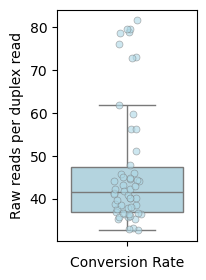

In [12]:
# subset data
df = subset_data[subset_data["PROJECT"].str.startswith("IDT")].copy()
df = df[df["PROJECT"].isin([
    'IDT007', 'IDT012', 'IDT013', 'IDT014',
    'IDT016', 'IDT017', 'IDT018','IDT020',
    'IDT015','IDT021', 'IDT022',
    'IDT023', 'IDT019',
    'IDT026',
    'IDT027',
])].copy()

mapping_batch_to_quality = {
    "Optimal": ['IDT007', 'IDT012', 'IDT013', 'IDT014',
                'IDT016', 'IDT017', 'IDT018','IDT020',
                'IDT026','IDT027',
                ],
    "Suboptimal" : ['IDT015','IDT021', 'IDT022',],
    "Failed": [ 'IDT023', 'IDT019']
}

df["CaptureStatus"] = df["PROJECT"].map({proj: status for status, projs in mapping_batch_to_quality.items() for proj in projs})
df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# your variables of interest
to_plot = [
    "OptimalReadXDuplexRead"
]
value = "Recovery"

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name=value
)


# set up plot (swapping x and y for horizontal orientation)
plt.figure(figsize=(1.8, 3))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    color = "lightblue",
    order = ["Optimal"],
    showfliers=False,
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    dodge=True,
    alpha=0.6,
    order = ["Optimal"],
    color = "lightblue",
    linewidth=0.5,
    edgecolor="gray",
    legend=False,

)

# tidy up
plt.title("", fontsize=12)
plt.ylabel("Raw reads per duplex read")
plt.xlabel("Conversion Rate")
plt.xticks([0],[])
plt.legend().remove()
# plt.tight_layout()
plt.savefig("../plots/sequencing_conversion_rate.deepDLP.pdf", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_259139/2218218976.py:49: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_259139/2218218976.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


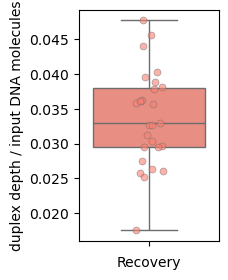

In [13]:
# subset data
df = subset_data[subset_data["PROJECT"].str.startswith("IDT")].copy()
df = df[df["PROJECT"].isin([
    'IDT007', 'IDT012', 'IDT013', 'IDT014',
    'IDT016', 'IDT017', 'IDT018','IDT020',
    'IDT015','IDT021', 'IDT022',
    'IDT023', 'IDT019',
    'IDT026',
    'IDT027',
])].copy()

mapping_batch_to_quality = {
    "Optimal": ['IDT007', 'IDT012', 'IDT013', 'IDT014',
                'IDT016', 'IDT017', 'IDT018','IDT020',
                'IDT026','IDT027',
                ],
    "Suboptimal" : ['IDT015','IDT021', 'IDT022',],
    "Failed": [ 'IDT023', 'IDT019']
}

df["CaptureStatus"] = df["PROJECT"].map({proj: status for status, projs in mapping_batch_to_quality.items() for proj in projs})
df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# your variables of interest
to_plot = [
    'Combined>>recovery.input_ng2duplex_depth',
]
value = "Recovery"

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name=value
)


# set up plot (swapping x and y for horizontal orientation)
plt.figure(figsize=(1.8, 3))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    color = "salmon",
    order = ["Optimal"],
    showfliers=False,
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    dodge=True,
    alpha=0.6,
    order = ["Optimal"],
    color = "salmon",
    linewidth=0.5,
    edgecolor="gray",
    legend=False,

)

# # tidy up
plt.title("", fontsize=12)
plt.ylabel("duplex depth / input DNA molecules")
plt.xlabel("Recovery")
plt.xticks([0],[])
plt.legend().remove()
plt.savefig("../plots/recovery_plot.deepDLP.pdf", dpi=300, bbox_inches='tight')
plt.show()

### ALT deepDLP metrics figures for supplementary note 1

In [14]:
alt_subset_data = data_to_use[~(data_to_use["PROJECT"].str.startswith("IDT"))
                                & ~(data_to_use["REAL_MEAN_DEPTH_ONTARGET"].isna())
                                ].copy()

alt_subset_data.shape

(29, 17)

/tmp/ipykernel_259139/467558862.py:33: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_259139/467558862.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


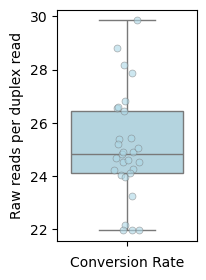

In [15]:
# subset data
df = alt_subset_data[alt_subset_data["OptimalReadXDuplexRead"]<60].copy()

df["CaptureStatus"] = "Optimal"
df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# your variables of interest
to_plot = [
    "OptimalReadXDuplexRead"
    # 'DryLab>>on_target.duplex.efficiency',
]
value = "Recovery"

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name=value
)


# set up plot (swapping x and y for horizontal orientation)
plt.figure(figsize=(1.8, 3))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    color = "lightblue",
    order = ["Optimal"],
    showfliers=False,
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    dodge=True,
    alpha=0.6,
    order = ["Optimal"],
    color = "lightblue",
    linewidth=0.5,
    edgecolor="gray",
    legend=False,

)

# tidy up
plt.title("", fontsize=12)
plt.ylabel("Raw reads per duplex read")
plt.xlabel("Conversion Rate")
plt.xticks([0],[])
plt.legend().remove()
# plt.tight_layout()
plt.savefig("../plots/sequencing_conversion_rate.ALT_deepDLP.pdf", dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_259139/3203247619.py:32: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_259139/3203247619.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


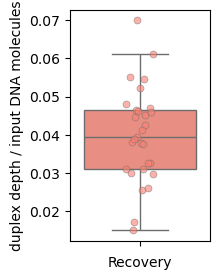

In [16]:
# subset data
df = alt_subset_data.copy()

df["CaptureStatus"] = "Optimal"
df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# your variables of interest
to_plot = [
    'Combined>>recovery.input_ng2duplex_depth',
]
value = "Recovery"

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name=value
)


# set up plot (swapping x and y for horizontal orientation)
plt.figure(figsize=(1.8, 3))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    color = "salmon",
    order = ["Optimal"],
    showfliers=False,
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    dodge=True,
    alpha=0.6,
    order = ["Optimal"],
    color = "salmon",
    linewidth=0.5,
    edgecolor="gray",
    legend=False,

)

# # tidy up
plt.title("", fontsize=12)
plt.ylabel("duplex depth / input DNA molecules")
plt.xlabel("Recovery")
plt.xticks([0],[])
plt.legend().remove()
plt.savefig("../plots/recovery_plot.ALT_deepDLP.pdf", dpi=300, bbox_inches='tight')
plt.show()
